# FashionMNIST Classification using MLP

## Objective
The objective of this task is to build a Multi-Layer Perceptron (MLP) model using PyTorch to classify images from the FashionMNIST dataset.

## Requirements
- Use FashionMNIST dataset
- Build an MLP model
- Achieve at least 80% accuracy
- Evaluate using confusion matrix and classification metrics
- Tune one hyperparameter and explain the choice

## Author
Ashwin Himmo Jass

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Set random seed
torch.manual_seed(123)
np.random.seed(123)

In [10]:
# Load FashionMNIST dataset

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Use subset (IMPORTANT for task)
train_subset = Subset(train_dataset, range(10000))
test_subset = Subset(test_dataset, range(2000))

# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

print("Data loaded successfully")

Data loaded successfully


## Data Loading

The FashionMNIST dataset was loaded and transformed into tensors.  
A subset of the dataset was used to reduce computation time:
- 10,000 training samples  
- 2,000 test samples  

DataLoaders were used to efficiently batch and shuffle the data.

In [11]:
# Define MLP model

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
        
    def forward(self, x):
        return self.model(x)

model = MLP()
print(model)

MLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


## Model Architecture

A Multi-Layer Perceptron (MLP) was used with:
- Input layer: 784 neurons (28x28 image)
- Hidden layers: 128 and 64 neurons
- Output layer: 10 classes

ReLU activation was used for non-linearity.

In [12]:
# Define loss function and optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function and optimizer set successfully")

Loss function and optimizer set successfully


## Hyperparameter Choice

The hyperparameter chosen for tuning is the learning rate.

A learning rate of 0.001 was selected because it is commonly used with the Adam optimizer and provides a good balance between learning speed and stability. A value that is too high can make training unstable, while a value that is too low can make training very slow.

In [13]:
# Train the model

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/10], Loss: 0.9288
Epoch [2/10], Loss: 0.5531
Epoch [3/10], Loss: 0.4820
Epoch [4/10], Loss: 0.4441
Epoch [5/10], Loss: 0.4047
Epoch [6/10], Loss: 0.3909
Epoch [7/10], Loss: 0.3733
Epoch [8/10], Loss: 0.3613
Epoch [9/10], Loss: 0.3455
Epoch [10/10], Loss: 0.3238


## Model Training

The model was trained for 10 epochs using the Adam optimizer and cross-entropy loss.  
Training loss was monitored at the end of each epoch to observe learning progress.

In [14]:
# Evaluate the model

model.eval()
correct = 0
total = 0

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.numpy())

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 86.20%


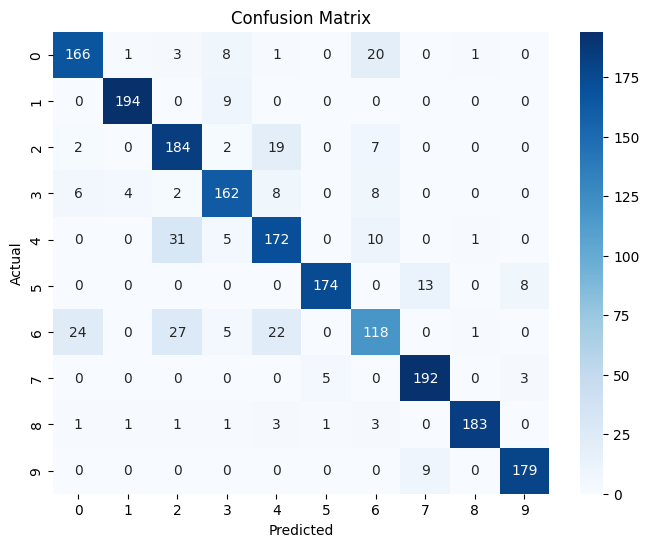

In [15]:
# Confusion Matrix

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [16]:
# Classification Report

report = classification_report(all_labels, all_predictions)
print(report)

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       200
           1       0.97      0.96      0.96       203
           2       0.74      0.86      0.80       214
           3       0.84      0.85      0.85       190
           4       0.76      0.79      0.77       219
           5       0.97      0.89      0.93       195
           6       0.71      0.60      0.65       197
           7       0.90      0.96      0.93       200
           8       0.98      0.94      0.96       194
           9       0.94      0.95      0.95       188

    accuracy                           0.86      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



## Model Evaluation

The model achieved a test accuracy of 86.20%, which exceeds the required 80% threshold.

### Confusion Matrix Analysis
The confusion matrix shows that most classes are predicted correctly, with strong diagonal values. However, some classes such as shirts, t-shirts, and pullovers are occasionally confused with each other due to visual similarities.

### Classification Metrics
The classification report provides precision, recall, and F1-score using macro averaging. The scores are generally consistent across classes, indicating balanced model performance.

### Challenging Classes
The model struggles most with visually similar clothing categories such as:
- T-shirt/top
- Shirt
- Pullover

These classes share similar shapes and textures, making them harder to distinguish.

### Conclusion
The MLP model performed well overall, achieving high accuracy and balanced classification metrics. With further tuning or a more complex model such as a CNN, performance could be improved further.